# 04. Comparativa US vs Europa

Analisis central para la estrategia de expansion europea de Lululemon.

**Preguntas clave:**
1. Hay diferencias de engagement entre US y Europa?
2. El sentimiento hacia Lululemon es diferente en Europa?
3. Que contenido funciona mejor en cada region?
4. Cuales son los pain points especificos de Europa?
5. Que paises europeos tienen mayor potencial?

In [1]:
import sys
sys.path.insert(0, "../../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotting import setup_style, save_fig, COLORS
setup_style()

DATA = "../../datos/clean"

ig_com = pd.read_csv(f"{DATA}/ig_comentarios_sentiment.csv")
tk_com = pd.read_csv(f"{DATA}/tiktok_comentarios_sentiment.csv")
tp = pd.read_csv(f"{DATA}/trustpilot_all_sentiment.csv")
tk = pd.read_csv(f"{DATA}/tiktok_videos.csv")

## 1. Engagement US vs Europa

/var/folders/hw/k9dl2bvx033g270sxxkmnwlw0000gn/T/ipykernel_94434/3478372456.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_us, data_eu], labels=["US", "Europa"], patch_artist=True,
/var/folders/hw/k9dl2bvx033g270sxxkmnwlw0000gn/T/ipykernel_94434/3478372456.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_us, data_eu], labels=["US", "Europa"], patch_artist=True,
/var/folders/hw/k9dl2bvx033g270sxxkmnwlw0000gn/T/ipykernel_94434/3478372456.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_us, data_eu], labels=["US", "Europa"], patch_artist=True,
/

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/comp_engagement_tiktok_us_vs_eu.png


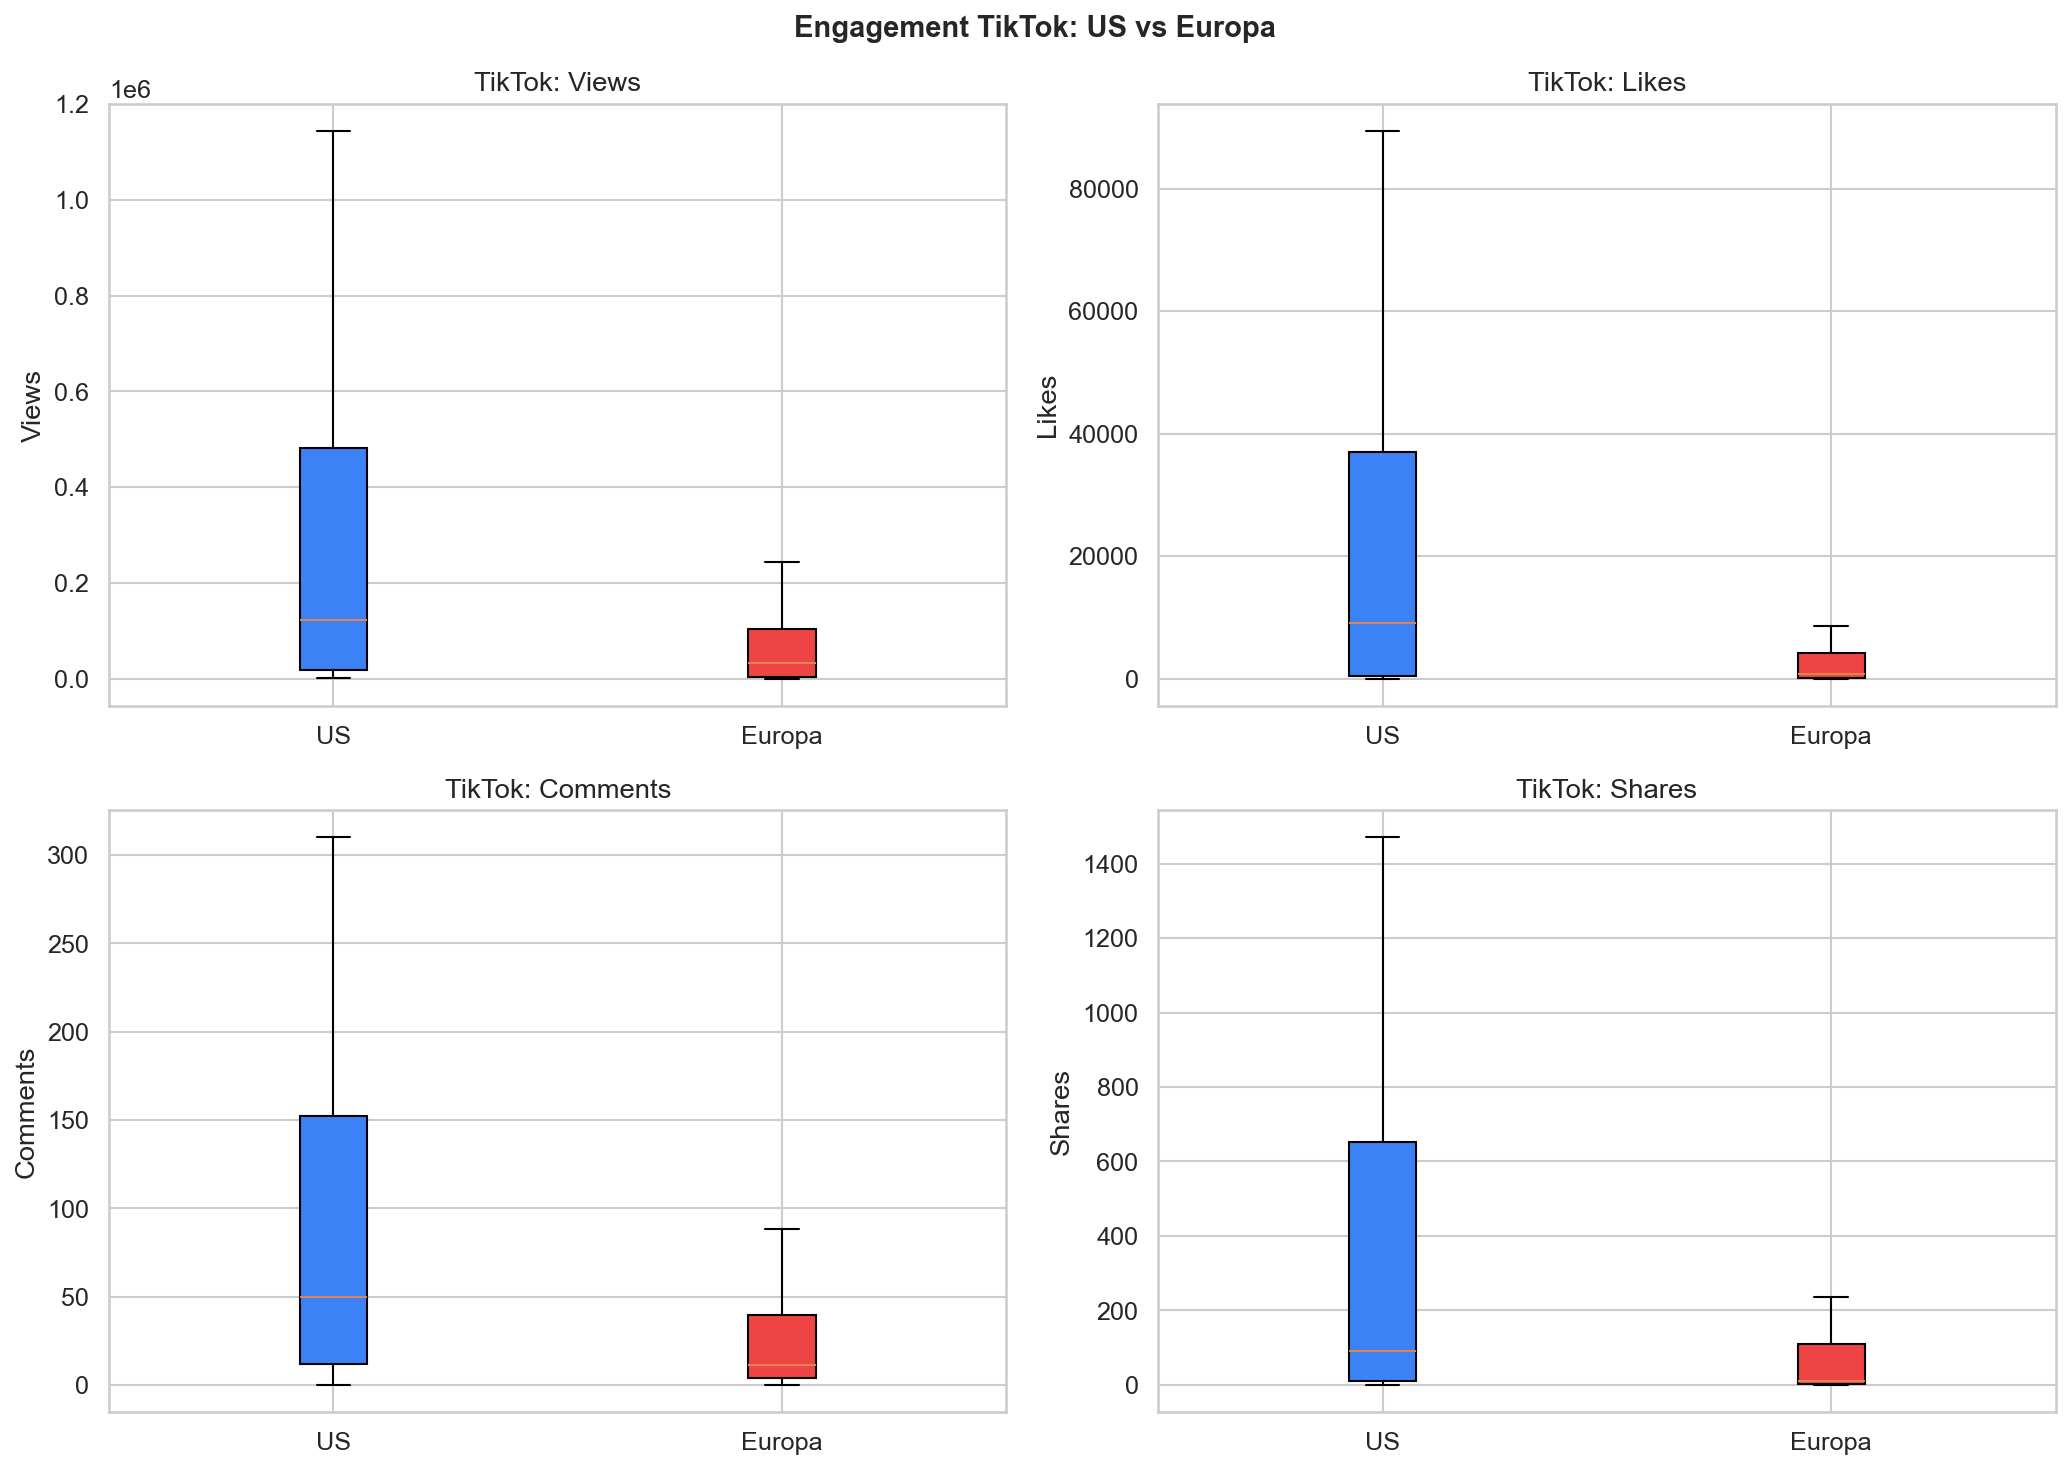

views: U=12738, p=0.0000 ***
likes: U=12992, p=0.0000 ***
comments: U=13314, p=0.0000 ***
shares: U=12994, p=0.0000 ***


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ["views", "likes", "comments", "shares"]
for ax, metric in zip(axes.flat, metrics):
    data_us = tk[tk["region_search"] == "US"][metric]
    data_eu = tk[tk["region_search"] == "Europe"][metric]

    bp = ax.boxplot([data_us, data_eu], labels=["US", "Europa"], patch_artist=True,
                    showfliers=False)
    bp["boxes"][0].set_facecolor(COLORS["us"])
    bp["boxes"][1].set_facecolor(COLORS["europe"])
    ax.set_title(f"TikTok: {metric.capitalize()}")
    ax.set_ylabel(metric.capitalize())

plt.suptitle("Engagement TikTok: US vs Europa", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig(fig, "comp_engagement_tiktok_us_vs_eu")
plt.show()

# Test estadistico
from scipy import stats
for metric in metrics:
    us_vals = tk[tk["region_search"]=="US"][metric].dropna()
    eu_vals = tk[tk["region_search"]=="Europe"][metric].dropna()
    stat, pval = stats.mannwhitneyu(us_vals, eu_vals, alternative="two-sided")
    print(f"{metric}: U={stat:.0f}, p={pval:.4f} {'***' if pval<0.01 else '**' if pval<0.05 else 'ns'}")

## 2. Sentimiento US vs Europa

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sent_order = ["positivo", "neutro", "negativo"]

# Asignar zonas
ig_com["zone"] = ig_com["region"].apply(lambda x: "US" if x == "US" else "Europa")
tk_com["zone"] = tk_com["region_search"].apply(lambda x: "US" if x == "US" else "Europa")

EU_COUNTRIES = ["GB","ES","DE","FR","NL","IE","IT","FI","RO","AT","BE","PT","SE","DK","NO","CH"]
tp_lulu = tp[tp["brand"] == "Lululemon"].copy()
tp_lulu["zone"] = tp_lulu["country"].apply(lambda x: "US" if x in ["US","CA"] else ("Europa" if x in EU_COUNTRIES else "Otro"))

# Instagram: US vs Europa (toda Europa)
for zone, offset, color in [("US", -0.18, COLORS["us"]), ("Europa", 0.18, COLORS["europe"])]:
    sub = ig_com[ig_com["zone"] == zone]
    counts = sub["sentiment_label"].value_counts(normalize=True).reindex(sent_order, fill_value=0)
    bars = axes[0].bar([x + offset for x in range(3)], counts.values, 0.35, label=f"{zone} (n={len(sub)})", color=color, alpha=0.85)
    for bar, val in zip(bars, counts.values):
        if val > 0.03:
            axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val*100:.0f}%", ha="center", fontsize=9, fontweight="bold")

axes[0].set_xticks(range(3))
axes[0].set_xticklabels(sent_order, fontsize=11)
axes[0].set_title("Instagram: Sentimiento por region", fontweight="bold")
axes[0].set_ylabel("Proporcion")
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 0.95)

# TikTok: US vs Europa
for zone, offset, color in [("US", -0.18, COLORS["us"]), ("Europa", 0.18, COLORS["europe"])]:
    sub = tk_com[tk_com["zone"] == zone]
    counts = sub["sentiment_label"].value_counts(normalize=True).reindex(sent_order, fill_value=0)
    bars = axes[1].bar([x + offset for x in range(3)], counts.values, 0.35, label=f"{zone} (n={len(sub)})", color=color, alpha=0.85)
    for bar, val in zip(bars, counts.values):
        if val > 0.03:
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val*100:.0f}%", ha="center", fontsize=9, fontweight="bold")

axes[1].set_xticks(range(3))
axes[1].set_xticklabels(sent_order, fontsize=11)
axes[1].set_title("TikTok: Sentimiento por region", fontweight="bold")
axes[1].set_ylabel("Proporcion")
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 0.65)

# Trustpilot: US vs Europa
for zone, offset, color in [("US", -0.18, COLORS["us"]), ("Europa", 0.18, COLORS["europe"])]:
    sub = tp_lulu[tp_lulu["zone"] == zone]
    if len(sub) == 0:
        continue
    counts = sub["sentiment_label"].value_counts(normalize=True).reindex(sent_order, fill_value=0)
    bars = axes[2].bar([x + offset for x in range(3)], counts.values, 0.35, label=f"{zone} (n={len(sub)})", color=color, alpha=0.85)
    for bar, val in zip(bars, counts.values):
        if val > 0.03:
            axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val*100:.0f}%", ha="center", fontsize=9, fontweight="bold")

axes[2].set_xticks(range(3))
axes[2].set_xticklabels(sent_order, fontsize=11)
axes[2].set_title("Trustpilot: Sentimiento por region", fontweight="bold")
axes[2].set_ylabel("Proporcion")
axes[2].legend(fontsize=10)
axes[2].set_ylim(0, 1.05)

plt.suptitle("Sentimiento US vs Europa por plataforma", fontsize=15, fontweight="bold")
plt.tight_layout()
save_fig(fig, "comp_sentimiento_us_vs_eu")
plt.show()

In [4]:
# Asignar zonas
ig_com["zone"] = ig_com["region"].apply(lambda x: "US" if x == "US" else "Europa")
tk_com["zone"] = tk_com["region_search"].apply(lambda x: "US" if x == "US" else "Europa")

# Tabla IG por zona
regions_ig = ig_com.groupby("zone").agg(
    n=("text_clean", "count"),
    sent_media=("sentiment_stars", "mean"),
    pct_positivo=("sentiment_label", lambda x: (x == "positivo").mean() * 100),
    pct_negativo=("sentiment_label", lambda x: (x == "negativo").mean() * 100),
).round(1)
regions_ig.index.name = "region"

# Tabla IG detallada por pais europeo
ig_eu = ig_com[ig_com["zone"] == "Europa"]
paises_ig = ig_eu.groupby("region").agg(
    n=("text_clean", "count"),
    sent_media=("sentiment_stars", "mean"),
    pct_positivo=("sentiment_label", lambda x: (x == "positivo").mean() * 100),
    pct_negativo=("sentiment_label", lambda x: (x == "negativo").mean() * 100),
).round(1).sort_values("n", ascending=False)

# Tabla TK por zona
regions_tk = tk_com.groupby("zone").agg(
    n=("text_clean", "count"),
    sent_media=("sentiment_stars", "mean"),
    pct_positivo=("sentiment_label", lambda x: (x == "positivo").mean() * 100),
    pct_negativo=("sentiment_label", lambda x: (x == "negativo").mean() * 100),
).round(1)
regions_tk.index.name = "region"

print("=== Instagram por zona ===")
display(regions_ig)
print("\n=== Instagram Europa por pais ===")
display(paises_ig)
print("\n=== TikTok por zona ===")
display(regions_tk)

regions_ig.to_csv("../../outputs/tablas/comp_sentimiento_ig_por_region.csv")
paises_ig.to_csv("../../outputs/tablas/comp_sentimiento_ig_paises_eu.csv")
regions_tk.to_csv("../../outputs/tablas/comp_sentimiento_tk_por_region.csv")

## 3. Pain points especificos de Europa

Analisis de los temas recurrentes en reviews negativos de Trustpilot para paises europeos.

In [5]:
EU_COUNTRIES = ["GB","ES","DE","FR","NL","IE","IT","FI","RO","AT","BE","PT","SE","DK","NO","CH"]
tp_lulu = tp[tp["brand"] == "Lululemon"].copy()
tp_lulu["zone"] = tp_lulu["country"].apply(lambda x: "US" if x in ["US","CA"] else ("Europa" if x in EU_COUNTRIES else "Otro"))

tp_lulu_eu = tp_lulu[tp_lulu["zone"] == "Europa"]
tp_lulu_eu_neg = tp_lulu_eu[tp_lulu_eu["sentiment_label"] == "negativo"]

print(f"Reviews europeas Lululemon: {len(tp_lulu_eu)}")
print(f"De las cuales negativas: {len(tp_lulu_eu_neg)} ({len(tp_lulu_eu_neg)/max(len(tp_lulu_eu),1)*100:.0f}%)")
print(f"\nPaises:")
print(tp_lulu_eu_neg["country"].value_counts())

print("\n--- Reviews negativas Europa (muestra) ---")
for _, row in tp_lulu_eu_neg.head(10).iterrows():
    print(f"\n[{row['country']}] Rating: {row['rating']} | {row.get('title_clean', '')}")
    print(f"  {str(row.get('text_clean', ''))[:200]}...")

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/comp_rating_por_pais.png


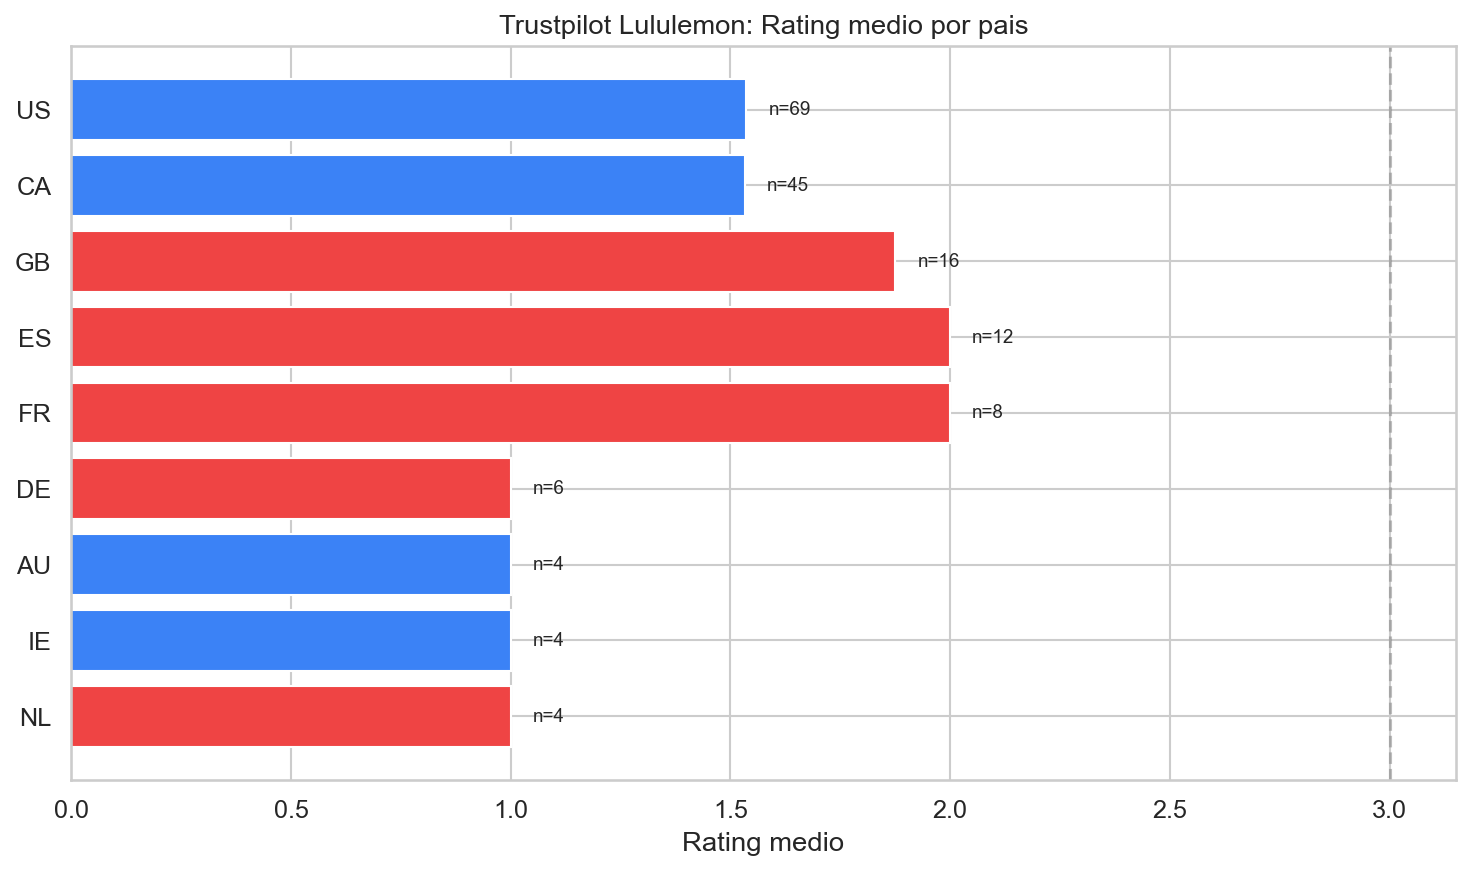

In [6]:
# Rating medio por pais
tp_lulu = tp[tp["brand"] == "Lululemon"]
country_ratings = tp_lulu.groupby("country").agg(
    n=("rating", "count"),
    rating_medio=("rating", "mean"),
    pct_1_2=("rating", lambda x: (x <= 2).mean() * 100),
).sort_values("n", ascending=False)

country_ratings = country_ratings[country_ratings["n"] >= 3]

fig, ax = plt.subplots(figsize=(10, 6))
colors = [COLORS["europe"] if c in ["ES", "FR", "GB", "DE", "IT", "NL", "BE"] else COLORS["us"]
          for c in country_ratings.index]
ax.barh(country_ratings.index[::-1], country_ratings["rating_medio"][::-1], color=colors[::-1])
ax.axvline(3, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Rating medio")
ax.set_title("Trustpilot Lululemon: Rating medio por pais")

for i, (idx, row) in enumerate(country_ratings[::-1].iterrows()):
    ax.text(row["rating_medio"] + 0.05, i, f"n={int(row['n'])}", va="center", fontsize=9)

plt.tight_layout()
save_fig(fig, "comp_rating_por_pais")
plt.show()

In [7]:
resumen_comp = pd.DataFrame({
    "Metrica": [
        "Sentimiento medio IG (US)", "Sentimiento medio IG (Europa)",
        "Sentimiento medio TK (US)", "Sentimiento medio TK (Europa)",
        "Rating Trustpilot (media global)",
        "% Negativo Trustpilot Europa (59 reviews)", "% Negativo Trustpilot US (114 reviews)",
    ],
    "Valor": [
        f"{ig_com[ig_com['zone']=='US']['sentiment_stars'].mean():.2f}",
        f"{ig_com[ig_com['zone']=='Europa']['sentiment_stars'].mean():.2f}",
        f"{tk_com[tk_com['zone']=='US']['sentiment_stars'].mean():.2f}",
        f"{tk_com[tk_com['zone']=='Europa']['sentiment_stars'].mean():.2f}",
        f"{tp_lulu['rating'].mean():.2f}",
        f"{(tp_lulu_eu['sentiment_label']=='negativo').mean()*100:.1f}%",
        f"{tp_lulu[tp_lulu['zone']=='US']['sentiment_label'].eq('negativo').mean()*100:.1f}%",
    ]
})
resumen_comp.to_csv("../../outputs/tablas/comp_resumen_us_vs_eu.csv", index=False)
resumen_comp